# Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm

In [2]:
_style = ('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid'
          in plt.style.available else 'seaborn-whitegrid')
plt.style.use(_style)
BLUE, CORAL, GREEN, AMBER, PURPLE = "#2563EB","#DC2626","#16A34A","#D97706","#7C3AED"
TEAL, GRAY = "#0891B2", "#374151"

In [3]:
data = pd.read_excel(r"C:\Users\hp\Desktop\Shreya\Datasets\Nashville Housing Cleaned Data.xlsx")

In [4]:
data.head()

,Row no.,UniqueID,ParcelID,Land Use,Sale Price,Legal Reference,Sold As Vacant,Owner Name,Acreage,TaxDistrict,...,Year Built,Bedrooms,Full Bath,Half Bath,Sale Date,Property Address_Street,Property City,Owner Street Address,Owner City Address,Owner State
0,1,2045,007 00 0 125.00,SINGLE FAMILY,240000,20130412-0036474,No,"FRAZIER, CYRENTHA LYNETTE",2.13,GENERAL SERVICES DISTRICT,...,1986,3,3,0,2013-04-09,1808 FOX CHASE DR,GOODLETTSVILLE,1808 FOX CHASE DR,GOODLETTSVILLE,TN
1,2,16918,007 00 0 130.00,SINGLE FAMILY,366000,20140619-0053768,No,"BONER, CHARLES & LESLIE",2.13,GENERAL SERVICES DISTRICT,...,1998,3,3,2,2014-06-10,1832 FOX CHASE DR,GOODLETTSVILLE,1832 FOX CHASE DR,GOODLETTSVILLE,TN
2,3,54582,007 00 0 138.00,SINGLE FAMILY,435000,20160927-0101718,No,"WILSON, JAMES E. & JOANNE",2.13,GENERAL SERVICES DISTRICT,...,1987,4,3,0,2016-09-26,1864 FOX CHASE DR,GOODLETTSVILLE,1864 FOX CHASE DR,GOODLETTSVILLE,TN
3,4,43070,007 00 0 143.00,SINGLE FAMILY,255000,20160129-0008913,No,"BAKER, JAY K. & SUSAN E.",2.13,GENERAL SERVICES DISTRICT,...,1985,3,3,0,2016-01-29,1853 FOX CHASE DR,GOODLETTSVILLE,1853 FOX CHASE DR,GOODLETTSVILLE,TN
4,5,22714,007 00 0 149.00,SINGLE FAMILY,278000,20141015-0095255,No,"POST, CHRISTOPHER M. & SAMANTHA C.",2.00,GENERAL SERVICES DISTRICT,...,1984,4,3,0,2014-10-10,1829 FOX CHASE DR,GOODLETTSVILLE,1829 FOX CHASE DR,GOODLETTSVILLE,TN


In [5]:
data["Sale Date"] = pd.to_datetime(data["Sale Date"])
 
print(f"Loaded: {data.shape[0]:,} rows × {data.shape[1]} columns")
original_cols = data.shape[1]

Loaded: 56,372 rows × 23 columns


###  (1) Log Transformation

================================================================================================================================
Sale Price, Land Value, Building Value, Total Value are all highly right-skewed (skew 3-30 in raw data, still right-skewed 
post-Winsor).
Log transformation reduces skewness and often improves residual normality, linearity, and variance stability for regression.
log1p(x) = log(1+x) handles zeros safely (Building Value has 1,852 zeros for vacant land parcels).

In [6]:
log_cols = ["Sale Price", "Land Value", "Building Value", "Total Value", "Acreage"]
for col in log_cols:
    data[f"log_{col.replace(' ', '_')}"] = np.log1p(data[col])

print("\n Log transforms created:")
for col in log_cols:
    orig_skew = data[col].skew()
    log_skew  = data[f"log_{col.replace(' ', '_')}"].skew()
    print(f" {col:<20} skew: {orig_skew:>7.3f} log skew: {log_skew:>7.3f}")


 Log transforms created:
 Sale Price           skew:   3.430 log skew:   0.059
 Land Value           skew:   3.556 log skew:   1.953
 Building Value       skew:   3.776 log skew:  -4.867
 Total Value          skew:   3.713 log skew:  -0.212
 Acreage              skew:   4.055 log skew:   3.198


#### Validation Plots

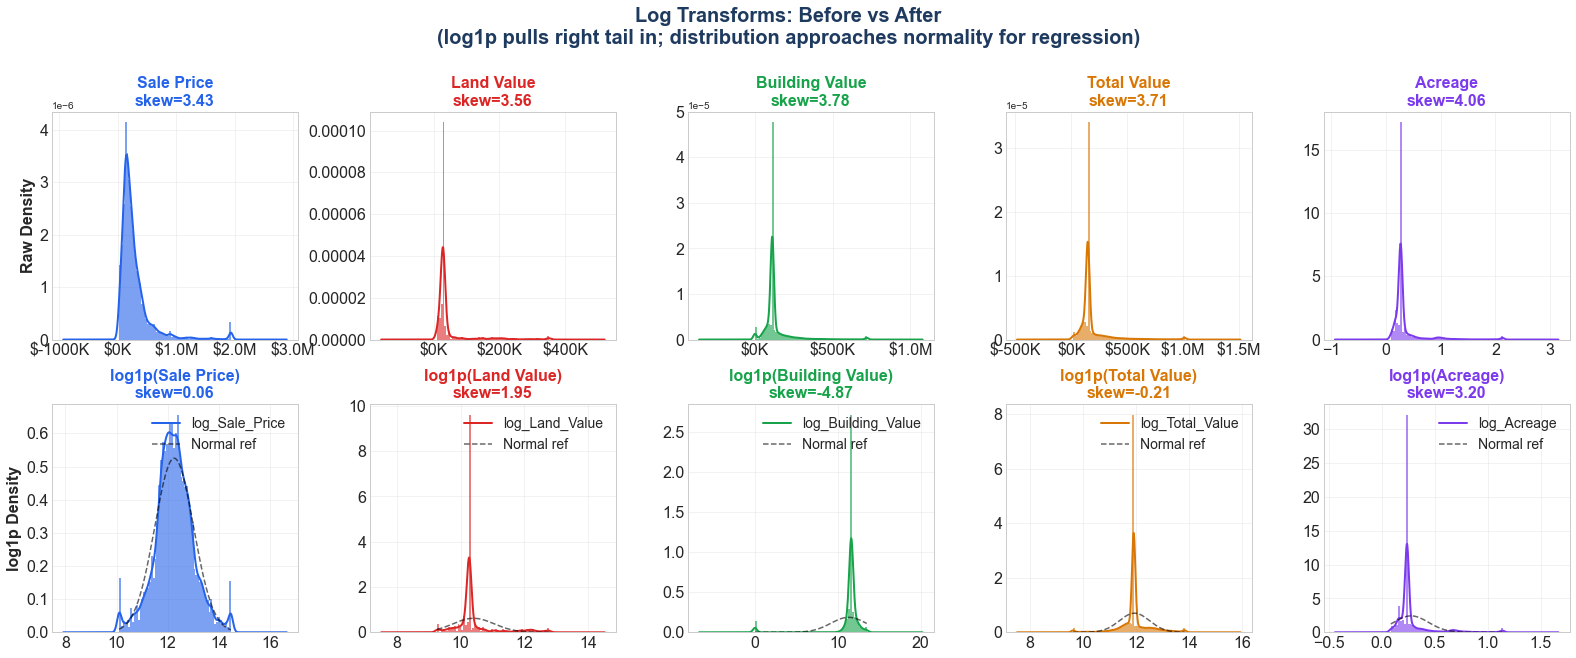

In [7]:
fig1, axes = plt.subplots(2, 5, figsize=(22, 9))
fig1.suptitle("Log Transforms: Before vs After\n"
              "(log1p pulls right tail in; distribution approaches normality for regression)",
              fontsize=20, fontweight="bold", color="#1E3A5F", y = 1.01)
 
raw_cols = ["Sale Price","Land Value","Building Value","Total Value","Acreage"]
log_names= ["log_Sale_Price","log_Land_Value","log_Building_Value","log_Total_Value","log_Acreage"]
colors   = [BLUE, CORAL, GREEN, AMBER, PURPLE]
 
for i, (raw, log, color) in enumerate(zip(raw_cols, log_names, colors)):
    # Raw
    ax = axes[0, i]
    s = data[raw].dropna()
    ax.hist(s, bins=60, color=color, alpha=0.6, density=True, edgecolor="none")
    s.plot.kde(ax=ax, color=color, linewidth=2)
    ax.set_title(f"{raw}\nskew={s.skew():.2f}", fontsize=16, fontweight="bold", color=color)
    ax.set_ylabel("Density" if i==0 else "", fontsize=14)
    ax.tick_params(labelsize=16)
    ax.grid(alpha=0.3)
    if raw in ["Sale Price","Land Value","Building Value","Total Value"]:
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x,_: f"${x/1e3:.0f}K" if x < 1e6 else f"${x/1e6:.1f}M"))
 
    # Log
    ax = axes[1, i]
    s_log = data[log].dropna()
    ax.hist(s_log, bins=60, color=color, alpha=0.6, density=True, edgecolor="none")
    s_log.plot.kde(ax=ax, color=color, linewidth=2)
    
    # Normal reference
    mu, sigma = s_log.mean(), s_log.std()
    x = np.linspace(s_log.min(), s_log.max(), 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color="black",
            linewidth=1.5, linestyle="--", alpha=0.6, label="Normal ref")
    ax.set_title(f"log1p({raw})\nskew={s_log.skew():.2f}", fontsize=16,
                 fontweight="bold", color=color)
    ax.set_ylabel("Density" if i==0 else "", fontsize=14)
    ax.tick_params(labelsize=16)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=14)

axes[0,0].set_ylabel("Raw Density", fontsize=16, fontweight="bold")
axes[1,0].set_ylabel("log1p Density", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

### (2) Property Age

================================================================================================================================
Year Built alone is hard for a model to interpret (1960 vs 2010 are just numbers).
Age at point of sale captures what matters: how old was the building when it was sold? Newer builds command premiums; very old builds either depreciate or appreciate as "historic" both are nonlinear effects.
A model can learn if age is correctly defined.
Use Sale Date year, not current year, so the feature is point-in-time.

#### Property Age distribution + age vs price

In [8]:
data["Sale_Year"]     = data["Sale Date"].dt.year
data["Sale_Month"]    = data["Sale Date"].dt.month
data["Sale_Quarter"]  = data["Sale Date"].dt.quarter
 
data["Property_Age"]  = data["Sale_Year"] - data["Year Built"]

# Cap negatives (data entry errors where Year Built > Sale Year)
data["Property_Age"]  = data["Property_Age"].clip(lower=0)
 
print(f"\n Property_Age created | range: {data['Property_Age'].min()}–{data['Property_Age'].max()} yrs"
      f" | median: {data['Property_Age'].median():.0f} yrs")
 
# Age squared captures the U-shape (very new AND very old both premium)
data["Property_Age_Sq"] = data["Property_Age"] ** 2


 Property_Age created | range: 0–184 yrs | median: 55 yrs


#### Decade Built Bins

================================================================================================================================
Year Built as a continuous variable conflates construction eras that have very different build quality, materials, 
and buyer perception. Binning into decades creates a meaningful ordinal variable: pre-1900 (historic), 1900-1950 (early 20th), 
etc. Easier to interpret in regression coefficients and cluster profiles. Also handles the imputed Year Built for vacant land
more gracefully (they all bin together rather than creating a fake trend).

In [9]:
decade_bins   = [0, 1899, 1919, 1939, 1959, 1979, 1999, 2010, 2024]
decade_labels = ["Pre-1900","1900-1919","1920-1939","1940-1959",
                 "1960-1979","1980-1999","2000-2009","2010-2024"]
 
data["Decade_Built"] = pd.cut(data["Year Built"], bins=decade_bins, labels=decade_labels, right=True)
 
# Ordinal encoding (preserves order for regression)
decade_order = {d: i for i, d in enumerate(decade_labels)}
data["Decade_Built_Ord"] = data["Decade_Built"].map(decade_order)
 
print(f"\n Decade_Built bins created:")
print(data["Decade_Built"].value_counts().sort_index().to_string())


 Decade_Built bins created:
Pre-1900       100
1900-1919      419
1920-1939     3526
1940-1959    20485
1960-1979    20610
1980-1999     3552
2000-2009      830
2010-2024     6850


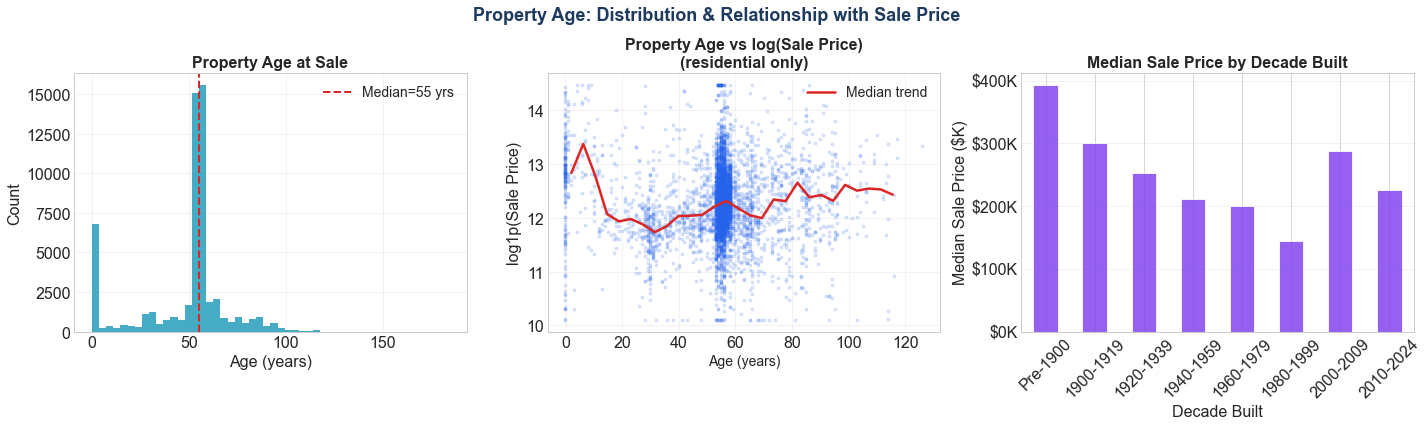

In [10]:
fig2, axes = plt.subplots(1, 3, figsize=(20, 6))
fig2.suptitle("Property Age: Distribution & Relationship with Sale Price",
              fontsize=18, fontweight="bold", color="#1E3A5F")
 
# Age histogram
ax = axes[0]
data["Property_Age"].hist(bins=50, ax=ax, color=TEAL, alpha=0.75, edgecolor="none")
ax.axvline(data["Property_Age"].median(), color=CORAL, linewidth=2,
           linestyle="--", label=f"Median={data['Property_Age'].median():.0f} yrs")
ax.set_title("Property Age at Sale", fontsize=16, fontweight="bold")
ax.set_xlabel("Age (years)", fontsize = 16)
ax.set_ylabel("Count",  fontsize = 16)
ax.tick_params(labelsize=16)
ax.legend(fontsize=14)
ax.grid(alpha=0.3)
 
# Age vs log price scatter (sample 5000 for speed)
ax = axes[1]
sample = data[data["Bedrooms"] > 0].sample(5000, random_state=42)
ax.scatter(sample["Property_Age"], sample["log_Sale_Price"], alpha=0.15, s=8, color=BLUE)

# Lowess trend
from scipy.stats import binned_statistic
bins_stat, bin_edges, _ = binned_statistic(
    sample["Property_Age"], sample["log_Sale_Price"], statistic="median", bins=30)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax.plot(bin_centers, bins_stat, color=CORAL, linewidth=2.5, label="Median trend")
ax.set_title("Property Age vs log(Sale Price)\n(residential only)", fontsize=16, fontweight="bold")
ax.set_xlabel("Age (years)", fontsize = 14)
ax.set_ylabel("log1p(Sale Price)",  fontsize = 16)
ax.tick_params(labelsize=16)
ax.legend(fontsize=14)
ax.grid(alpha=0.3)
 
# Decade built bar
ax = axes[2]
decade_median = data.groupby("Decade_Built", observed=True)["Sale Price"].median() / 1000
decade_median.plot(kind="bar", ax=ax, color=PURPLE, alpha=0.8, edgecolor="white")
ax.set_title("Median Sale Price by Decade Built", fontsize=16, fontweight="bold")
ax.set_xlabel("Decade Built", fontsize= 16)
ax.set_ylabel("Median Sale Price ($K)", fontsize= 16)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:.0f}K"))
ax.tick_params(axis="x", rotation=45, labelsize=16)
ax.tick_params(axis="y", labelsize=16)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

#### Justification for adding "property square age"  term

In [11]:
# Residential only vacant land has imputed Year Built so its age is meaningless
res = data[data["Bedrooms"] > 0][
    ["Property_Age", "Property_Age_Sq", "log_Sale_Price", "Sale Price"]
].dropna()

print(f"Working sample: {len(res):,} residential properties")
print(f"Age range: {res['Property_Age'].min():.0f} – {res['Property_Age'].max():.0f} years\n")

Working sample: 51,166 residential properties
Age range: 0 – 184 years



In [12]:
res["Age_Bin"] = pd.cut(res["Property_Age"],
                         bins=range(0, 201, 10), right=False)
bin_profile = (res.groupby("Age_Bin", observed=True)["Sale Price"]
                  .agg(["median", "count"])
                  .reset_index())
 
# Keep only bins with ≥ 50 properties (thin bins distort the trend)
bin_profile = bin_profile[bin_profile["count"] >= 50].copy()
bin_profile["Age_Mid"] = bin_profile["Age_Bin"].apply(lambda x: x.left + 5)
 
print("Median Sale Price by Age Bin:")
print("-" * 45)
for _, row in bin_profile.iterrows():
    bar = "█" * int(row["median"] / 10000)
    print(f"  {str(row['Age_Bin']):<12}  ${row['median']:>9,.0f}   n={row['count']:,}")

Median Sale Price by Age Bin:
---------------------------------------------
  [0, 10)       $  359,900   n=2,170
  [10, 20)      $  181,500   n=894
  [20, 30)      $  147,000   n=1,648
  [30, 40)      $  137,100   n=2,267
  [40, 50)      $  164,000   n=2,650
  [50, 60)      $  217,500   n=32,015
  [60, 70)      $  184,000   n=4,263
  [70, 80)      $  222,000   n=1,883
  [80, 90)      $  245,000   n=2,013
  [90, 100)     $  276,500   n=947
  [100, 110)    $  322,000   n=232
  [110, 120)    $  325,000   n=178


##### (i) OLS REGRESSION: linear vs quadratic

================================================================================================================================
Model 1:  log(Sale Price) = b0 + b1*Age
Model 2:  log(Sale Price) = b0 + b1*Age + b2·Age square

We use log(Sale Price) because the raw price is right-skewed.
OLS on log price = log-linear model (standard for real estate regression).


If b2 > 0  U-shape  (price dips then recovers)
If b2 < 0  inverted-U  (price peaks then falls)
If b2 ≈ 0  linear is sufficient, squaring adds nothing

Vertex formula:  Age_at_min = -b1 / (2 × b2)
This is the age where price is at its lowest point on the curve.

In [13]:
# Model 1: linear
X1 = sm.add_constant(res[["Property_Age"]])
model1 = sm.OLS(res["log_Sale_Price"], X1).fit()
 
# Model 2: quadratic (Age + Age square)
X2 = sm.add_constant(res[["Property_Age", "Property_Age_Sq"]])
model2 = sm.OLS(res["log_Sale_Price"], X2).fit()
 
# F-test: does adding Age square significantly improve the model?
ftest = anova_lm(model1, model2)
 
b0 = model2.params["const"]
b1 = model2.params["Property_Age"]
b2 = model2.params["Property_Age_Sq"]
vertex_age = -b1 / (2 * b2)    # age where price curve hits its minimum

In [14]:
print("\n" + "="*60)
print("REGRESSION RESULTS")
print("="*60)
 
print("\nModel 1: Linear only (Age):")
print(f"  log(Price) = {model1.params['const']:.4f} + {model1.params['Property_Age']:.6f}*Age")
print(f"  R-square   = {model1.rsquared:.5f}  (explains {model1.rsquared*100:.3f}% of variance)")
print(f"  AIC        = {model1.aic:.1f}")
print(f"  p(Age)     = {model1.pvalues['Property_Age']:.4f}  "
      f"{'NOT significant linear term useless alone' if model1.pvalues['Property_Age'] > 0.05 else 'significant'}")
 
print("\nModel 2: Quadratic (Age + Age square):")
print(f"  log(Price) = {b0:.4f} + ({b1:.6f})*Age + ({b2:.6f})*Age square")
print(f"  R-square   = {model2.rsquared:.5f}  (explains {model2.rsquared*100:.3f}% of variance)")
print(f"  AIC        = {model2.aic:.1f}  (lower = better fit)")
print(f"  p(Age)     = {model2.pvalues['Property_Age']:.2e} highly significant")
print(f"  p(Age square) = {model2.pvalues['Property_Age_Sq']:.2e} highly significant")
 
print(f"\nF-test (is Age square worth adding?):")
print(f"  F = {ftest['F'].iloc[1]:.2f},  p = {ftest['Pr(>F)'].iloc[1]:.2e}")
print(f" {'YES Age square significantly improves the model' if ftest['Pr(>F)'].iloc[1] < 0.05 else 'No'}")
 
print(f"\nCoefficient interpretation:")
print(f"  b2 = {b2:.6f} POSITIVE  confirmed U-shape")
print(f"  Vertex at age = -b1 / (2*b2) = -({b1:.6f}) / (2×{b2:.6f}) = {vertex_age:.1f} years")
print(f"  Properties ~{vertex_age:.0f} years old have the LOWEST predicted price")
print(f"  Both newer AND older properties command a premium over this age")


REGRESSION RESULTS

Model 1: Linear only (Age):
  log(Price) = 12.2664 + 0.000217*Age
  R-square   = 0.00003  (explains 0.003% of variance)
  AIC        = 108665.4
  p(Age)     = 0.2156  NOT significant linear term useless alone

Model 2: Quadratic (Age + Age square):
  log(Price) = 12.4956 + (-0.011233)*Age + (0.000121)*Age square
  R-square   = 0.01265  (explains 1.265% of variance)
  AIC        = 108017.8  (lower = better fit)
  p(Age)     = 2.92e-120 highly significant
  p(Age square) = 2.74e-143 highly significant

F-test (is Age square worth adding?):
  F = 653.74,  p = 2.74e-143
 YES Age square significantly improves the model

Coefficient interpretation:
  b2 = 0.000121 POSITIVE  confirmed U-shape
  Vertex at age = -b1 / (2*b2) = -(-0.011233) / (2×0.000121) = 46.5 years
  Properties ~47 years old have the LOWEST predicted price
  Both newer AND older properties command a premium over this age


In [15]:
# Percent price change per year interpretation
# In a log-linear model: %price ≈ b1 + 2*b2*Age
pct_at_0   = (b1 + 2*b2*0)   * 100
pct_at_30  = (b1 + 2*b2*30)  * 100
pct_at_60  = (b1 + 2*b2*60)  * 100
pct_at_100 = (b1 + 2*b2*100) * 100
print(f"\n  Marginal effect of 1 extra year of age on log(price):")
print(f"  At age  0:  {pct_at_0:+.2f}% per year  (new builds depreciating fast)")
print(f"  At age 30:  {pct_at_30:+.2f}% per year  (approaching the dip)")
print(f"  At age 60:  {pct_at_60:+.2f}% per year  (past dip, now appreciating)")
print(f"  At age 100: {pct_at_100:+.2f}% per year  (historic premium building)")
 
print(f"\n  AIC improved by {model1.aic - model2.aic:.1f} points with Age square")
print(f"  Rule of thumb: AIC > 2 = meaningful improvement")
print(f"  Keep Property_Age_Sq in the model ")


  Marginal effect of 1 extra year of age on log(price):
  At age  0:  -1.12% per year  (new builds depreciating fast)
  At age 30:  -0.40% per year  (approaching the dip)
  At age 60:  +0.32% per year  (past dip, now appreciating)
  At age 100: +1.29% per year  (historic premium building)

  AIC improved by 647.6 points with Age square
  Rule of thumb: AIC > 2 = meaningful improvement
  Keep Property_Age_Sq in the model 


#### (ii) Plots

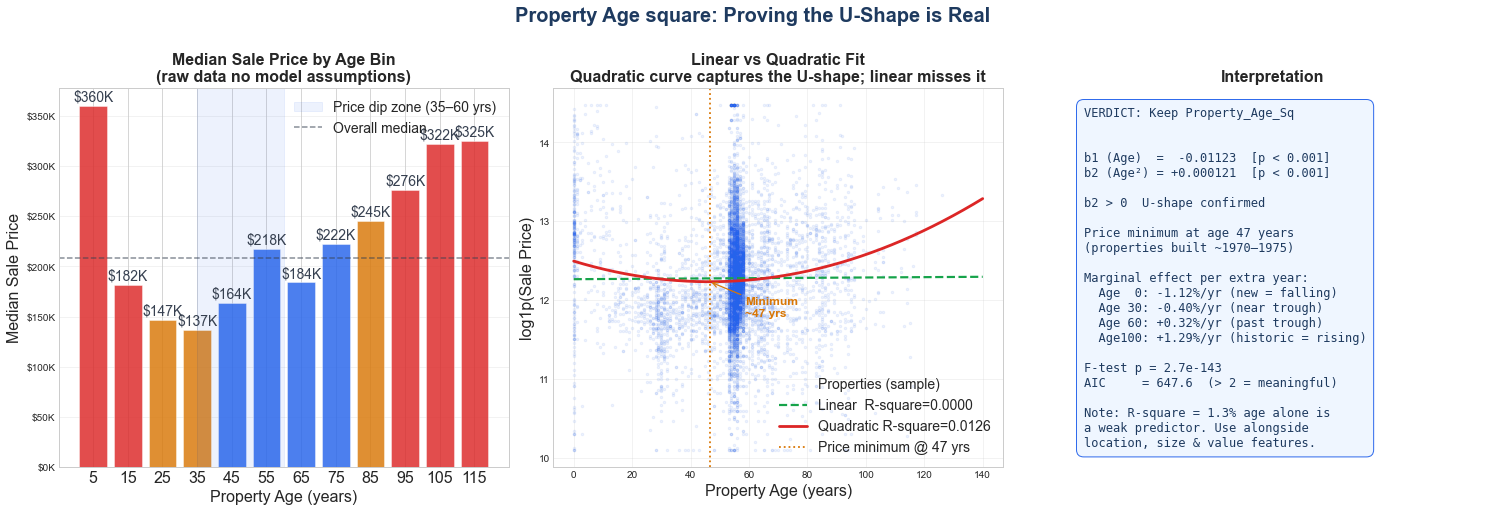

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle("Property Age square: Proving the U-Shape is Real",
             fontsize=20, fontweight="bold", color="#1E3A5F", y= 1.01)
 
# Panel 1: Median price by bin (raw evidence)
ax = axes[0]
colors_bar = [CORAL if row["Age_Mid"] < 20 or row["Age_Mid"] > 90
              else (AMBER if row["Age_Mid"] < 40 or row["Age_Mid"] > 75
              else BLUE)
              for _, row in bin_profile.iterrows()]
bars = ax.bar(bin_profile["Age_Mid"], bin_profile["median"] / 1000,
              width=8, color=colors_bar, alpha=0.82, edgecolor="white", linewidth=0.5)
ax.axvspan(35, 60, color=BLUE, alpha=0.08, label="Price dip zone (35–60 yrs)")
ax.axhline(res["Sale Price"].median() / 1000, color=GRAY,
           linewidth=1.5, linestyle="--", alpha=0.6, label="Overall median")
 
# Label each bar
for bar, (_, row) in zip(bars, bin_profile.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            f"${row['median']/1000:.0f}K",
            ha="center", va="bottom", fontsize=14, color=GRAY)

ax.set_title("Median Sale Price by Age Bin\n"
             "(raw data no model assumptions)",
             fontsize=16, fontweight="bold")
ax.set_xlabel("Property Age (years)", fontsize=16)
ax.set_ylabel("Median Sale Price", fontsize=16)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
ax.set_xticks(bin_profile["Age_Mid"])
ax.set_xticklabels([str(int(x)) for x in bin_profile["Age_Mid"]],
                   rotation=0, fontsize=16)

ax.legend(fontsize=14)
ax.grid(axis="y", alpha=0.3)
 
# Panel 2: Scatter + both fitted curves 
ax = axes[1]
sample = res.sample(8000, random_state=42)
ax.scatter(sample["Property_Age"], sample["log_Sale_Price"],
           alpha=0.08, s=6, color=BLUE, label="Properties (sample)")
 
x_fit = np.linspace(0, 140, 400)
 
# Linear curve
c1 = model1.params
y_linear = c1["const"] + c1["Property_Age"] * x_fit
ax.plot(x_fit, y_linear, color=GREEN, linewidth=2.2,
        linestyle="--", label=f"Linear  R-square={model1.rsquared:.4f}")
 
# Quadratic curve
y_quad = b0 + b1 * x_fit + b2 * x_fit**2
ax.plot(x_fit, y_quad, color=CORAL, linewidth=2.8,
        label=f"Quadratic R-square={model2.rsquared:.4f}")
 
# Mark vertex
ax.axvline(vertex_age, color=AMBER, linewidth=1.8,
           linestyle=":", label=f"Price minimum @ {vertex_age:.0f} yrs")

ax.annotate(f"Minimum\n~{vertex_age:.0f} yrs",
            xy=(vertex_age, b0 + b1*vertex_age + b2*vertex_age**2),
            xytext=(vertex_age + 12, 11.8),
            fontsize=12, color=AMBER, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=AMBER, lw=1.2))
 
ax.set_title("Linear vs Quadratic Fit\n"
             "Quadratic curve captures the U-shape; linear misses it", fontsize=16, fontweight="bold")
ax.set_xlabel("Property Age (years)", fontsize=16)
ax.set_ylabel("log1p(Sale Price)", fontsize=16)

ax.legend(fontsize=14, loc="lower right"); ax.grid(alpha=0.3)
 
# Panel 3: Coefficient summary + verdict
ax = axes[2]
ax.axis("off")
 
verdict_text = (
    "VERDICT: Keep Property_Age_Sq\n"
    "\n\n"
    f"b1 (Age)  =  {b1:.5f}  [p < 0.001]\n"
    f"b2 (Age²) = +{b2:.6f}  [p < 0.001]\n\n"
    
    f"b2 > 0  U-shape confirmed\n\n"
    f"Price minimum at age {vertex_age:.0f} years\n"
    f"(properties built ~1970–1975)\n\n"
    f"Marginal effect per extra year:\n"
    f"  Age  0: {pct_at_0:+.2f}%/yr (new = falling)\n"
    f"  Age 30: {pct_at_30:+.2f}%/yr (near trough)\n"
    f"  Age 60: {pct_at_60:+.2f}%/yr (past trough)\n"
    f"  Age100: {pct_at_100:+.2f}%/yr (historic = rising)\n\n"
    f"F-test p = {ftest['Pr(>F)'].iloc[1]:.1e}\n"
    f"AIC     = {model1.aic - model2.aic:.1f}  (> 2 = meaningful)\n\n"
    f"Note: R-square = 1.3% age alone is\n"
    f"a weak predictor. Use alongside\n"
    f"location, size & value features."
)
ax.text(0.08, 0.95, verdict_text,
        transform=ax.transAxes,
        fontsize=12, color="#1E3A5F",
        va="top", ha="left", family="monospace",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#EFF6FF", edgecolor=BLUE, alpha=0.95))

ax.set_title("Interpretation", fontsize=16, fontweight="bold")
 
plt.tight_layout()

plt.show()

### (3) Price per Acre

================================================================================================================================
A dollar 500K property on 0.1 acres is fundamentally different from a dollar 500K property on 2 acres. 
Price per acre is the standard real-estate density metric. 
Strong signal for regression and cluster separation.
Acreage Q1=Q3=0.27 after Winsorization (heavily imputed). For vacant land the ratio is meaningful; 
for condos (which report near-zero acreage) it inflates artificially. Flag condo rows.
Use log of the ratio in regression (it's also right-skewed).

In [17]:
# Only compute where Acreage > 0 
data["Price_Per_Acre"]     = data["Sale Price"] / data["Acreage"]
data["log_Price_Per_Acre"] = np.log1p(data["Price_Per_Acre"])
 
# Flag condo-type rows where acreage is unreliable
condo_mask = data["Land Use"].isin(["RESIDENTIAL CONDO", "CONDO",
                                   "CONDOMINIUM OFC OR OTHER COM CONDO"])
data["Acreage_Reliable"] = (~condo_mask).astype(int)  # 1 = reliable, 0 = condo
 
print(f"\n Price_Per_Acre created  | median: ${data['Price_Per_Acre'].median():,.0f}/acre"
      f"  | condo rows flagged: {condo_mask.sum():,}")


 Price_Per_Acre created  | median: $727,778/acre  | condo rows flagged: 14,346


### (4) Price Ratios

================================================================================================================================
The ratio of sale price to assessed total value is a classic measure of market premium or discount. 
A ratio > 1 means buyers paid above assessed;  < 1 means below. This captures market heat that raw prices alone miss.
Land value share shows whether value is in the land (location-driven) or the building (structure-driven) 
very different property types.

Total Value = 0 for some vacant parcels divide-by-zero. Handle with np.where. 
Assessed values lag the market so treat ratio as directional.

In [18]:
data["Sale_to_Assessed_Ratio"] = np.where(
    data["Total Value"] > 0,
    data["Sale Price"] / data["Total Value"],
    np.nan
)
 
data["Land_Value_Share"] = np.where(
    data["Total Value"] > 0,
    data["Land Value"] / data["Total Value"],
    np.nan
)
 
data["Building_Value_Share"] = np.where(
    data["Total Value"] > 0,
    data["Building Value"] / data["Total Value"],
    np.nan
)
 
print(f"\n Price ratios created")
print(f" Sale_to_Assessed_Ratio  median: {data['Sale_to_Assessed_Ratio'].median():.3f}"
      f"  (>1 = paid above assessed)")
print(f" Land_Value_Share      median: {data['Land_Value_Share'].median():.3f}"
      f"  (share of value in land)")
print(f" Building_Value_Share    median: {data['Building_Value_Share'].median():.3f}"
      f"  (share of value in structure)")


 Price ratios created
 Sale_to_Assessed_Ratio  median: 1.292  (>1 = paid above assessed)
 Land_Value_Share      median: 0.194  (share of value in land)
 Building_Value_Share    median: 0.750  (share of value in structure)


#### Land Use Simplification

================================================================================================================================
39 Land Use categories is too granular for modelling. Many categories have only 1-3 rows. 
Collapsing to 7 meaningful groups gives adequate sample sizes per group for hypothesis testing (target n > 30 per group) and
avoids overfitting in regression dummy encoding.

In [19]:
land_use_map = {
    "SINGLE FAMILY"                              : "Single Family",
    "ZERO LOT LINE"                              : "Single Family",
    "MOBILE HOME"                                : "Single Family",
    "PARSONAGE"                                  : "Single Family",
    "RESIDENTIAL CONDO"                          : "Condo",
    "CONDO"                                      : "Condo",
    "CONDOMINIUM OFC OR OTHER COM CONDO"         : "Condo",
    "DUPLEX"                                     : "Multi-Family",
    "TRIPLEX"                                    : "Multi-Family",
    "QUADPLEX"                                   : "Multi-Family",
    "RESIDENTIAL COMBO/MISC"                     : "Multi-Family",
    "SPLIT CLASS"                                : "Multi-Family",
    "APARTMENT: LOW RISE (BUILT SINCE 1960)"     : "Multi-Family",
    "DORMITORY/BOARDING HOUSE"                   : "Multi-Family",
    "VACANT RESIDENTIAL LAND"                    : "Vacant",
    "VACANT COMMERCIAL LAND"                     : "Vacant",
    "VACANT RURAL LAND"                          : "Vacant",
    "VACANT ZONED MULTI FAMILY"                  : "Vacant",
    "GREENBELT"                                  : "Vacant",
    "GREENBELT/RES GRRENBELT/RES"                : "Vacant",
    "FOREST"                                     : "Vacant",
    "PARKING LOT"                                : "Vacant",
}

In [20]:
# Everything not in the map Commercial/Institutional
data["Land_Use_Group"] = data["Land Use"].map(land_use_map).fillna("Commercial/Institutional")
 
print(f"\n Land_Use_Group created (7 groups):")
print(data["Land_Use_Group"].value_counts().to_string())


 Land_Use_Group created (7 groups):
Single Family               35192
Condo                       14346
Vacant                       5147
Multi-Family                 1635
Commercial/Institutional       52


#### Plots: Price Per Acre + Price Ratios

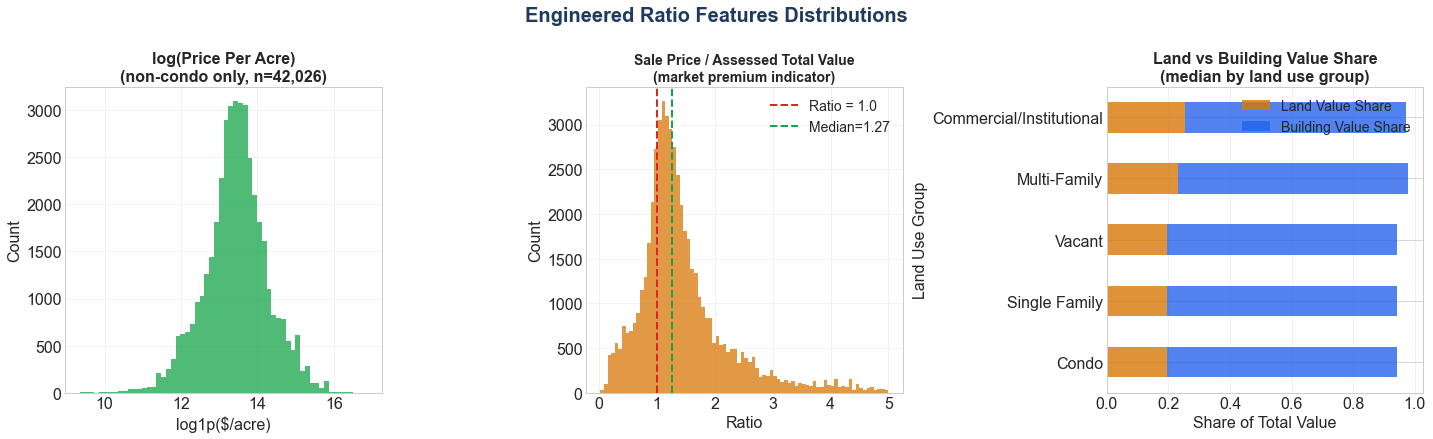

In [21]:
fig3, axes = plt.subplots(1, 3, figsize=(20, 6))
fig3.suptitle("Engineered Ratio Features Distributions",
              fontsize=20, fontweight="bold", color="#1E3A5F", y = 1.01)
 
# Price per acre (reliable rows only)
ax = axes[0]
ppa = data[data["Acreage_Reliable"]==1]["log_Price_Per_Acre"].dropna()
ppa.hist(bins=60, ax=ax, color=GREEN, alpha=0.75, edgecolor="none")
ax.set_title(f"log(Price Per Acre)\n(non-condo only, n={len(ppa):,})",
             fontsize=16, fontweight="bold")
ax.set_xlabel("log1p($/acre)", fontsize=16)
ax.set_ylabel("Count", fontsize=16)
ax.tick_params(labelsize=16)
ax.grid(alpha=0.3)
 
# Sale to Assessed ratio
ax = axes[1]
ratio = data["Sale_to_Assessed_Ratio"].dropna()
ratio = ratio[ratio < 5]  # remove extreme encoding errors for viz
ratio.hist(bins=80, ax=ax, color=AMBER, alpha=0.75, edgecolor="none")
ax.axvline(1.0, color=CORAL, linewidth=2, linestyle="--", label="Ratio = 1.0")
ax.axvline(ratio.median(), color=GREEN, linewidth=2,
           linestyle="--", label=f"Median={ratio.median():.2f}")

ax.set_title("Sale Price / Assessed Total Value\n(market premium indicator)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Ratio", fontsize=16)
ax.set_ylabel("Count", fontsize=16)
ax.tick_params(labelsize=16)
ax.legend(fontsize=14)
ax.grid(alpha=0.3)
 
# Land vs Building value share (stacked bar by land use group)
ax = axes[2]
group_shares = data.groupby("Land_Use_Group")[["Land_Value_Share","Building_Value_Share"]].median()
group_shares = group_shares.sort_values("Land_Value_Share", ascending=True)
group_shares.plot(kind="barh", stacked=True, ax=ax,
                  color=[AMBER, BLUE], alpha=0.8, edgecolor="none")
ax.set_title("Land vs Building Value Share\n(median by land use group)",
             fontsize=16, fontweight="bold")
ax.set_xlabel("Share of Total Value", fontsize=16)
ax.set_ylabel("Land Use Group", fontsize=16)

ax.legend(["Land Value Share","Building Value Share"], fontsize=14)
ax.grid(axis="x", alpha=0.3)
ax.tick_params(labelsize=16)
 
plt.tight_layout()

plt.show()

### (5) Bath Features

================================================================================================================================
Bedrooms and bath counts are correlated but each adds independent signal.
Total_Baths combines them on a standard scale (half bath = 0.5).
Bath_to_Bed_Ratio captures luxury density (3 baths, 2 beds = luxury condo).
Bath_Score is a weighted composite used in real-estate appraisal.
For vacant land Bedrooms=0 and Full Bath=0 by domain cap, so ratios will be 0 or undefined.

1) Total_Baths: Counts the total bathrooms on a standardized scale
                A half bath (toilet + sink only, no shower/tub) is counted as 0.5 because it's not a full bathroom.

2) Bath_Score: A weighted score used in real-estate appraisal.
               Same formula here, but the intent is different it's a quality/value score, not just a count.
               
3) Bath_to_Bed_Ratio: Luxury density indicator.
                      A ratio of ~0.67 means roughly 2 baths per 3 bedrooms on average.

4) Size_Proxy: A rough size estimate without square footage.

In [22]:
data["Total_Baths"]  = data["Full Bath"] + 0.5 * data["Half Bath"]
data["Bath_Score"]   = data["Full Bath"] * 1.0 + data["Half Bath"] * 0.5
 
# Ratio only meaningful for residential (bedrooms > 0)
data["Bath_to_Bed_Ratio"] = np.where(
    data["Bedrooms"] > 0,
    data["Total_Baths"] / data["Bedrooms"],
    np.nan
)
 
# Size proxy: weighted composite of rooms
data["Size_Proxy"] = data["Bedrooms"] * 2 + data["Full Bath"] * 1.5 + data["Half Bath"] * 0.5
 
print(f"\n Bath features created")
print(f" Total_Baths  median: {data['Total_Baths'].median():.1f}")
print(f" Bath_to_Bed_Ratio median: {data['Bath_to_Bed_Ratio'].median():.2f}"
      f" (NaN for {data['Bath_to_Bed_Ratio'].isna().sum():,} vacant rows)")


 Bath features created
 Total_Baths  median: 2.0
 Bath_to_Bed_Ratio median: 0.67 (NaN for 5,206 vacant rows)


### (6) Price Category

In [23]:
data["Price_Category"] = pd.qcut(
    data["Sale Price"],
    q=4,
    labels=["Budget", "Mid-Range", "Upper-Mid", "Luxury"]
)
 
print(f"\n Price_Category (quartile-based):")
print(data["Price_Category"].value_counts().sort_index().to_string())


 Price_Category (quartile-based):
Budget       14212
Mid-Range    13974
Upper-Mid    14123
Luxury       14063


### (7) Sale Temporal Features  (already done year/month/quarter above)

================================================================================================================================
Nashville had significant price appreciation 2013-2019. Year captures market trend. 
Quarter captures seasonality (spring = peak selling season).

In [24]:
# Hot market: post-2016 Nashville boom
data["Hot_Market_Era"] = (data["Sale_Year"] >= 2016).astype(int)
 
print(f"\n Temporal features: Sale_Year, Sale_Month, Sale_Quarter, Hot_Market_Era")
print(data["Sale_Year"].value_counts().sort_index().to_string())


 Temporal features: Sale_Year, Sale_Month, Sale_Quarter, Hot_Market_Era
2013    11292
2014    14274
2015    16733
2016    14071
2019        2


### (8) Plots

#### (i) Bath features + Price Category + Land Use Group

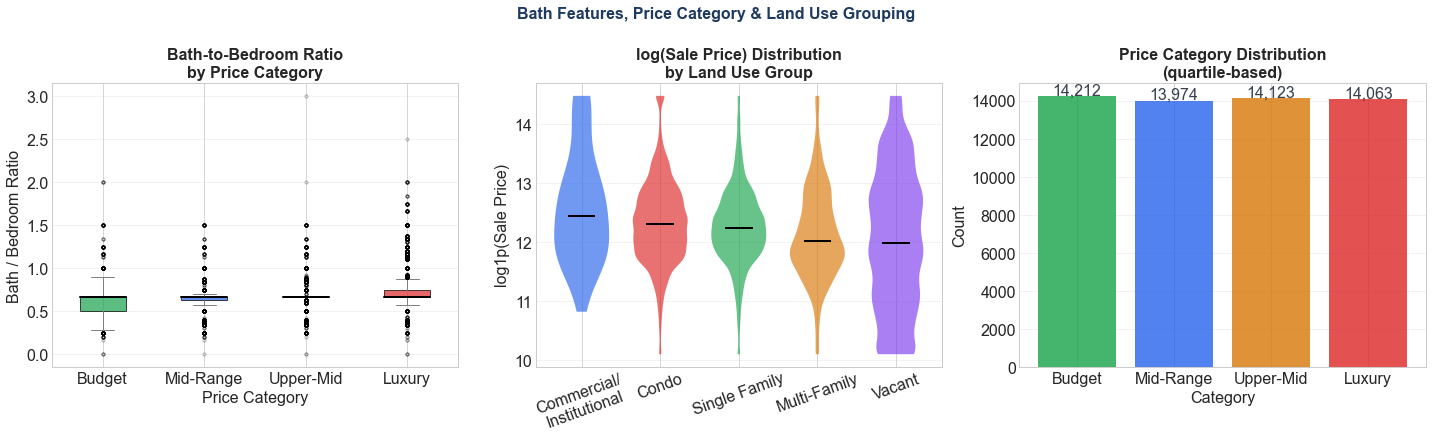

In [25]:
fig4, axes = plt.subplots(1, 3, figsize=(20, 6))
fig4.suptitle("Bath Features, Price Category & Land Use Grouping",
              fontsize=16, fontweight="bold", color="#1E3A5F", y = 1.01)
 
# Bath to Bed Ratio by Price Category
ax = axes[0]
order = ["Budget","Mid-Range","Upper-Mid","Luxury"]
bp_data = [data[data["Price_Category"]==cat]["Bath_to_Bed_Ratio"].dropna() for cat in order]
bp = ax.boxplot(bp_data, patch_artist=True, notch=False,
                medianprops=dict(color="black", linewidth=2),
                flierprops=dict(marker="o", markersize=3, alpha=0.3),
                whiskerprops=dict(color="gray"),
                capprops=dict(color="gray"))

for patch, color in zip(bp["boxes"], [GREEN, BLUE, AMBER, CORAL]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
    
ax.set_xticklabels(order, fontsize=16)
ax.set_title("Bath-to-Bedroom Ratio\nby Price Category", fontsize=16, fontweight="bold")
ax.set_xlabel("Price Category", fontsize = 16)
ax.set_ylabel("Bath / Bedroom Ratio", fontsize = 16)
ax.tick_params(labelsize=16)
ax.grid(axis="y", alpha=0.3)
 
# Price by Land Use Group violin
ax = axes[1]
group_order = (data.groupby("Land_Use_Group")["Sale Price"]
               .median().sort_values(ascending=False).index.tolist())

colors_v = [BLUE,CORAL,GREEN,AMBER,PURPLE,TEAL,"#EC4899"]
for i, (grp, color) in enumerate(zip(group_order, colors_v)):
    grp_data = data[data["Land_Use_Group"]==grp]["log_Sale_Price"].dropna()
    parts = ax.violinplot(grp_data, positions=[i], widths=0.7,
                          showmedians=True, showextrema=False)
    for pc in parts["bodies"]:
        pc.set_facecolor(color); pc.set_alpha(0.65)
    parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(2)
    
ax.set_xticks(range(len(group_order)))
ax.set_xticklabels([g.replace("/","/\n") for g in group_order], fontsize=16, rotation=20)
ax.set_title("log(Sale Price) Distribution\nby Land Use Group", fontsize=16, fontweight="bold")
ax.set_ylabel("log1p(Sale Price)", fontsize = 16)
ax.tick_params(labelsize=16)
ax.grid(axis="y", alpha=0.3)
 
# Price category counts
ax = axes[2]
pc_counts = data["Price_Category"].value_counts().reindex(order)
bars = ax.bar(order, pc_counts.values,
              color=[GREEN, BLUE, AMBER, CORAL], alpha=0.8, edgecolor="none")
for bar, val in zip(bars, pc_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100, f"{val:,}", ha="center", fontsize=16, color=GRAY)
    
ax.set_title("Price Category Distribution\n(quartile-based)", fontsize=16, fontweight="bold")
ax.set_xlabel("Category", fontsize=16)
ax.set_ylabel("Count", fontsize = 16)
ax.tick_params(labelsize=16)
ax.grid(axis="y", alpha=0.3)
 
plt.tight_layout()

plt.show()

#### (ii) Sale Year trend + Hot Market Era

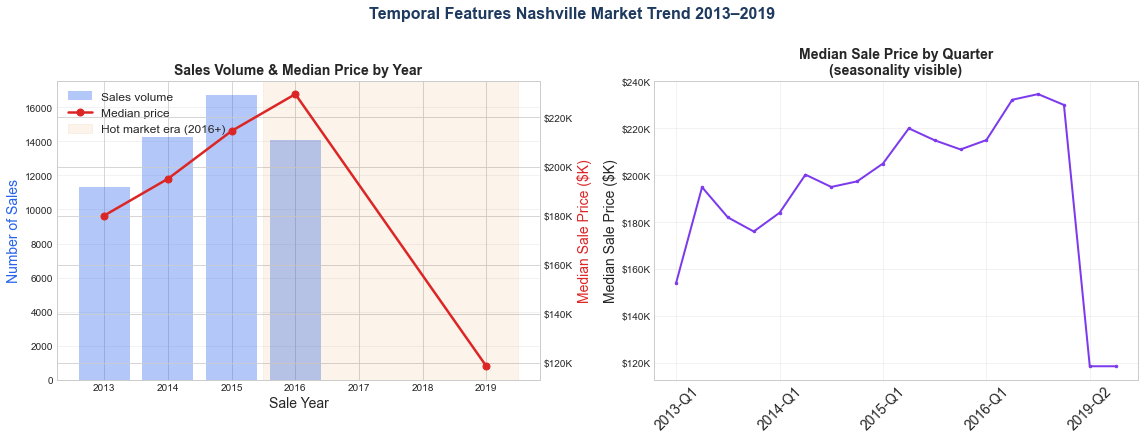

In [26]:
fig5, axes = plt.subplots(1, 2, figsize=(16, 6))
fig5.suptitle("Temporal Features Nashville Market Trend 2013–2019",
              fontsize=16, fontweight="bold", color="#1E3A5F", y=1.01)
 
ax = axes[0]
yearly = data.groupby("Sale_Year")["Sale Price"].agg(["median","count"]).reset_index()
ax2 = ax.twinx()
ax.bar(yearly["Sale_Year"], yearly["count"], color=BLUE, alpha=0.35, label="Sales volume")

ax2.plot(yearly["Sale_Year"], yearly["median"]/1000, color=CORAL,
         linewidth=2.5, marker="o", markersize=7, label="Median price")

ax2.axvspan(2015.5, 2019.5, color=AMBER, alpha=0.08, label="Hot market era (2016+)")

ax.set_xlabel("Sale Year", fontsize = 14)
ax.set_ylabel("Number of Sales", color=BLUE, fontsize = 14)
ax2.set_ylabel("Median Sale Price ($K)", color=CORAL, fontsize = 14)

ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:.0f}K"))
ax.set_title("Sales Volume & Median Price by Year", fontsize=14, fontweight="bold")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=12, loc="upper left")
ax.grid(axis="y", alpha=0.3)
 
ax = axes[1]
quarterly = data.groupby(["Sale_Year","Sale_Quarter"])["Sale Price"].median().reset_index()
quarterly["Period"] = quarterly["Sale_Year"].astype(str) + "-Q" + quarterly["Sale_Quarter"].astype(str)
ax.plot(range(len(quarterly)), quarterly["Sale Price"]/1000,
        color=PURPLE, linewidth=2, marker=".", markersize=5)

ax.set_xticks(range(0, len(quarterly), 4))
ax.set_xticklabels(quarterly["Period"].iloc[::4], rotation=45, fontsize=14)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:.0f}K"))
ax.set_title("Median Sale Price by Quarter\n(seasonality visible)", fontsize=14, fontweight="bold")
ax.set_ylabel("Median Sale Price ($K)", fontsize = 14)
ax.grid(alpha=0.3)
 
plt.tight_layout()

plt.show()

================================================================================================================================
The dataset jumps from 2016 directly to 2019 with only 2 records i.e. 2017 and 2018 are essentially absent from the data. 

So the quarterly chart has:
Q1–Q4 visible for 2013–2016 
A massive gap where 2017–2018 data is missing
Then just one or two 2019 quarters at the far right, which also explains the sudden price drop at the end, 
two records can't represent a true median

### (9) Sold as Vacant

In [27]:
# Binary encoding

data["Sold_As_Vacant_enc"] = (
    data["Sold As Vacant"]
    .str.strip()
    .str.upper()
    .map({"YES":1, "NO":0})
)

In [28]:
# SAVE

out1 = r'C:\Users\hp\Desktop\Shreya\Datasets\Nashville Housing Feature Engineered Data.xlsx'
data.to_excel(out1, index=False)